In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

In [2]:
strats = fread('stratified_genome_metadata.tsv')
setnames(strats, 'genome_ID', 'genome')

In [3]:
tools = c('singlem', 'metaphlan', 'motus', 'kraken', 'sourmash', 'kaiju', 'map2b', 'metabuli')
# Tools that do not have the correct taxonomy are tested only at the domain level. eg. Kaiju has NCBI taxonomy and MAP2B uses GTDB v202
correct_taxonomy_tools = c('singlem', 'metaphlan', 'kraken', 'sourmash', 'metabuli')

publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'MetaPhlAn', 'mOTUs', 'Kraken2', 'sourmash', 'Kaiju', 'MAP2B', 'Metabuli')
)
name_to_publication_name = function(names, correct_taxonomy_only=F){
    to_return = c()
    for (name in names){
        to_return = c(to_return, publication_names[tool==name]$publication_name)
    }
    if (correct_taxonomy_only){
        return(factor(to_return, levels=publication_names[tool %in% correct_taxonomy_tools]$publication_name))
    } else {
        return(factor(to_return, levels=publication_names$publication_name))
    }
}

In [4]:
d1 = data.table(expand.grid(tool=tools, genome=strats$genome))
d1[, method := 'relabund']
d1[tool=='kraken', method := 'reads_wise']
d1[tool=='kaiju', method := 'reads_wise']
d1[tool=='metabuli', method := 'reads_wise']
d1[1:3]

tool,genome,method
<fct>,<fct>,<chr>
singlem,GCA_019422935.1_genomic,relabund
metaphlan,GCA_019422935.1_genomic,relabund
motus,GCA_019422935.1_genomic,relabund


In [5]:
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
d2 = d1[, fread(paste('output_',tool,sep='','/opal/',genome,'.',method,'.opal_report')), by=list(tool,genome)]
d2[1:3]

tool,genome,tool,rank,metric,sample,value
<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>
singlem,GCA_019422935.1_genomic,Gold standard,kingdom,Bray-Curtis distance,SAMPLEID,0
singlem,GCA_019422935.1_genomic,Gold standard,phylum,Bray-Curtis distance,SAMPLEID,0
singlem,GCA_019422935.1_genomic,Gold standard,class,Bray-Curtis distance,SAMPLEID,0


In [6]:
dim(d2)

[1] 170178      7

In [7]:
setnames(d2, c('tool','genome','blah','rank','metric','sample','value'))
d3 = d2[blah != 'Gold standard'][,.(tool, genome, rank, metric, value)]
d3[1:3]
dim(d3)

tool,genome,rank,metric,value
<fct>,<fct>,<chr>,<chr>,<dbl>
singlem,GCA_019422935.1_genomic,kingdom,Bray-Curtis distance,0.03182257
singlem,GCA_019422935.1_genomic,phylum,Bray-Curtis distance,0.02292683
singlem,GCA_019422935.1_genomic,class,Bray-Curtis distance,0.02292683


[1] 82818     5

In [8]:
bc = d3[metric=='Bray-Curtis distance']
dim(bc)
bc[1:10]

[1] 5880    5

tool,genome,rank,metric,value
<fct>,<fct>,<chr>,<chr>,<dbl>
singlem,GCA_019422935.1_genomic,kingdom,Bray-Curtis distance,0.03182257
singlem,GCA_019422935.1_genomic,phylum,Bray-Curtis distance,0.02292683
singlem,GCA_019422935.1_genomic,class,Bray-Curtis distance,0.02292683
singlem,GCA_019422935.1_genomic,order,Bray-Curtis distance,0.02292683
singlem,GCA_019422935.1_genomic,family,Bray-Curtis distance,0.02292683
singlem,GCA_019422935.1_genomic,genus,Bray-Curtis distance,0.02029836
singlem,GCA_019422935.1_genomic,species,Bray-Curtis distance,0.49066798
metaphlan,GCA_019422935.1_genomic,kingdom,Bray-Curtis distance,0.11033920
metaphlan,GCA_019422935.1_genomic,phylum,Bray-Curtis distance,0.11033920


In [9]:
bc2 = merge(bc, strats, by='genome')
bc2[1:10]

genome,tool,rank,metric,value,novelty_category,taxonomy
<chr>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>
GCA_013154095.1_genomic,singlem,kingdom,Bray-Curtis distance,0.00521119,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,singlem,phylum,Bray-Curtis distance,0.39070856,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,singlem,class,Bray-Curtis distance,0.38370521,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,singlem,order,Bray-Curtis distance,0.37029361,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,singlem,family,Bray-Curtis distance,0.33564140,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,singlem,genus,Bray-Curtis distance,0.33564140,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,singlem,species,Bray-Curtis distance,0.33564140,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,metaphlan,kingdom,Bray-Curtis distance,0.50000000,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,metaphlan,phylum,Bray-Curtis distance,0.50000000,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095


In [10]:
orders = c('kingdom','phylum','class','order','family','genus','species')
novel_orders = gsub('^','novel ',orders)
bc2[, rank := factor(rank, levels=orders)]
bc2[, novelty_category := factor(novelty_category, levels=orders)]

In [11]:
bc2[, kingdom := gsub('d__', 'novel ', gsub(';.*','',taxonomy))]
bc2[, novelty_category_novel := factor(gsub('^','novel ',novelty_category), levels=novel_orders)]
bc2[1:3]

genome,tool,rank,metric,value,novelty_category,taxonomy,kingdom,novelty_category_novel
<chr>,<fct>,<fct>,<chr>,<dbl>,<fct>,<chr>,<chr>,<fct>
GCA_013154095.1_genomic,singlem,kingdom,Bray-Curtis distance,0.00521119,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095,novel Archaea,novel phylum
GCA_013154095.1_genomic,singlem,phylum,Bray-Curtis distance,0.39070856,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095,novel Archaea,novel phylum
GCA_013154095.1_genomic,singlem,class,Bray-Curtis distance,0.38370521,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095,novel Archaea,novel phylum


Warning message:
“`qplot()` was deprecated in ggplot2 3.4.0.”


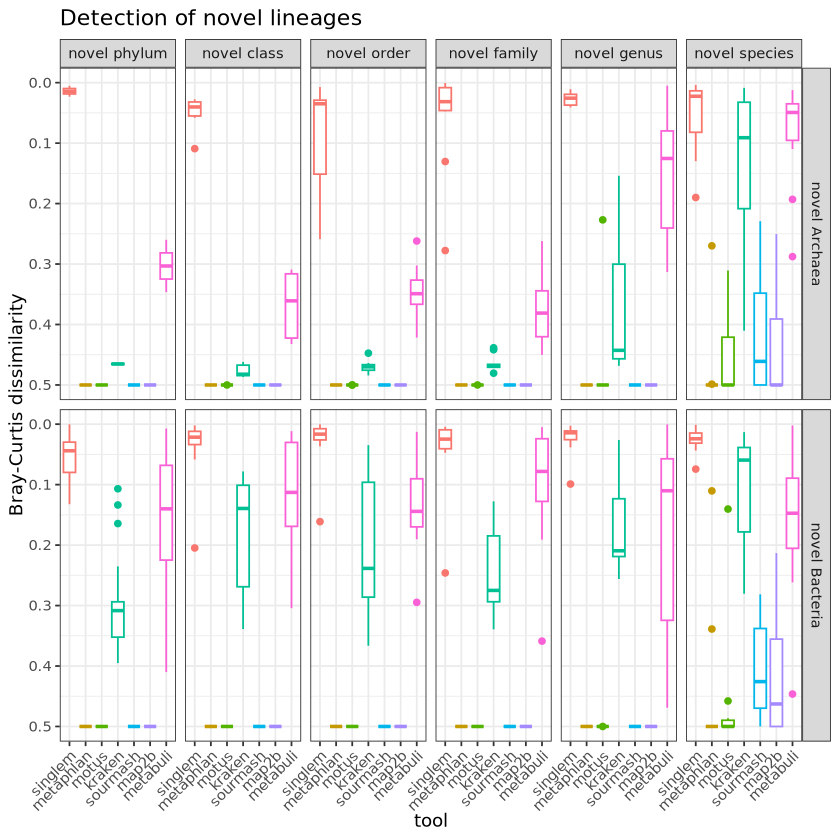

In [ ]:
qplot(data=bc2[rank=='kingdom'], tool, value, geom='boxplot', main='Detection of novel lineages', colour=tool, ylab='Bray-Curtis dissimilarity') +
  facet_grid(kingdom~novelty_category_novel) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(legend.position='none') +
  scale_y_reverse()

In [13]:
# stats
bc2[rank=='kingdom', .(ave=mean(value), sd=sd(value)), by=list(tool)]

tool,ave,sd
<fct>,<dbl>,<dbl>
singlem,0.04459283,0.05546575
metaphlan,0.49348031,0.04354851
motus,0.49057410,0.04611520
kraken,0.27945371,0.15285222
sourmash,0.48506794,0.05025703
map2b,0.48845407,0.04737303
metabuli,0.18640079,0.13988852


In [14]:
bc2[rank=='kingdom' & kingdom=='novel Archaea', .(ave=mean(value), sd=sd(value)), by=list(tool)]

tool,ave,sd
<fct>,<dbl>,<dbl>
singlem,0.05500932,0.06793737
metaphlan,0.49517659,0.03321439
motus,0.48509037,0.05090384
kraken,0.38160765,0.15339155
sourmash,0.48144218,0.06027869
map2b,0.48863935,0.04608825
metabuli,0.25717737,0.14188326


In [15]:
bc2[rank=='kingdom' & kingdom=='novel Bacteria', .(ave=mean(value), sd=sd(value)), by=list(tool)]

tool,ave,sd
<fct>,<dbl>,<dbl>
singlem,0.03764851,0.04448285
metaphlan,0.49234945,0.04944764
motus,0.49422992,0.04260441
kraken,0.21135109,0.10874422
sourmash,0.48748512,0.04258203
map2b,0.48833055,0.04853104
metabuli,0.13921640,0.11759268


In [16]:
bc2[rank=='kingdom' & novelty_category=='species', .(ave=mean(value), sd=sd(value)), by=list(tool)]

tool,ave,sd
<fct>,<dbl>,<dbl>
singlem,0.04165777,0.04750104
metaphlan,0.46088184,0.10264308
motus,0.45709890,0.08954343
kraken,0.12552233,0.11964052
sourmash,0.41040766,0.09369229
map2b,0.43072442,0.09922732
metabuli,0.12231379,0.11486859


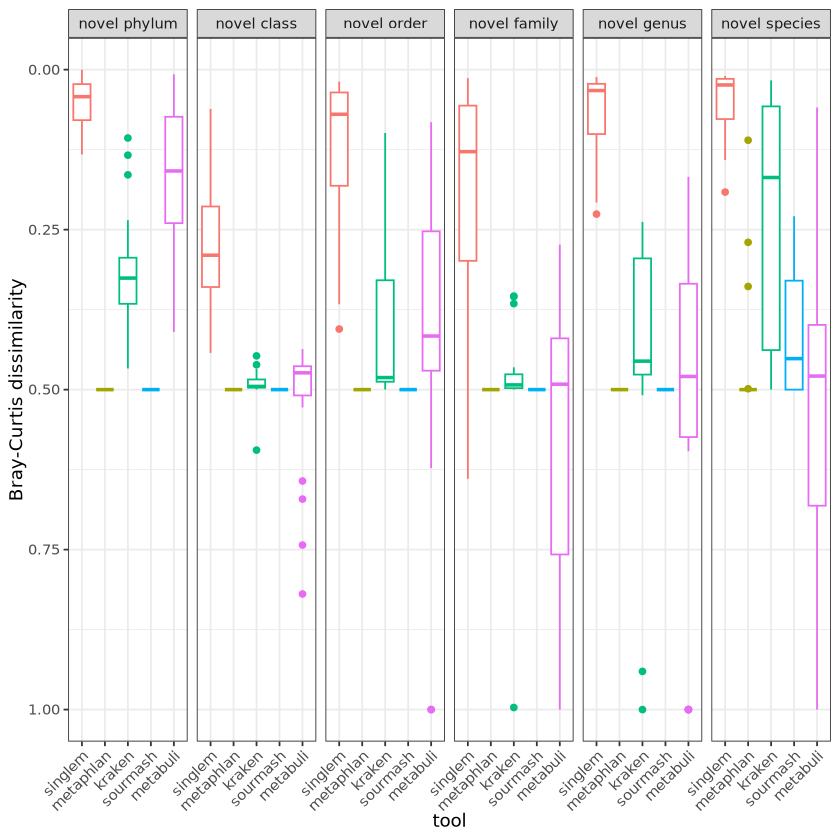

In [17]:
# What about when the rank equals the novelty category?
qplot(data=bc2[tool %in% correct_taxonomy_tools][rank==orders[as.numeric(novelty_category)-1]], ylab='Bray-Curtis dissimilarity', tool, colour=tool, value, geom='boxplot')+facet_grid(.~novelty_category_novel)+theme(axis.text.x = element_text(angle = 45, hjust = 1))+theme(legend.position='none')+scale_y_reverse()

In [18]:
# stats
bc2[tool %in% correct_taxonomy_tools][rank==orders[as.numeric(novelty_category)-1]][, .(ave=mean(value), sd=sd(value)), by=list(tool)]

tool,ave,sd
<fct>,<dbl>,<dbl>
singlem,0.1265524,0.13429256
metaphlan,0.4934803,0.04354851
kraken,0.3969939,0.16887578
sourmash,0.4851699,0.04985119
metabuli,0.4537833,0.25713906


In [19]:
bc2[tool %in% correct_taxonomy_tools][tool != 'singlem'][rank==orders[as.numeric(novelty_category)-1]][, .(ave=mean(value), sd=sd(value)), by=list(tool)][,.(ave=mean(ave), sd=mean(sd))]

ave,sd
<dbl>,<dbl>
0.4573569,0.1298536


In [20]:
bc2[tool == 'singlem' & novelty_category_novel=='novel class'][rank==orders[as.numeric(novelty_category)-1]][order(-value)]

genome,tool,rank,metric,value,novelty_category,taxonomy,kingdom,novelty_category_novel
<chr>,<fct>,<fct>,<chr>,<dbl>,<fct>,<chr>,<chr>,<fct>
GCA_024720975.1_genomic,singlem,phylum,Bray-Curtis distance,0.44259622,class,d__Archaea;p__Thermoproteota;c__JANJXX01;o__JANJXX01;f__JANJXX01;g__JANJXX01;s__JANJXX01 sp024720975,novel Archaea,novel class
GCA_021803575.1_genomic,singlem,phylum,Bray-Curtis distance,0.42631579,class,d__Bacteria;p__Bacillota_E;c__JAJZYS01;o__JAJZYS01;f__JAJZLH01;g__JAJZLH01;s__JAJZLH01 sp021803575,novel Bacteria,novel class
GCA_021163045.1_genomic,singlem,phylum,Bray-Curtis distance,0.42217548,class,d__Archaea;p__Thermoproteota;c__JANJXX01;o__JANJXX01;f__JANJXX01;g__JAGGXM01;s__JAGGXM01 sp021163045,novel Archaea,novel class
GCA_023475165.1_genomic,singlem,phylum,Bray-Curtis distance,0.37086345,class,d__Bacteria;p__Bacillota_E;c__JAMCWA01;o__JAMCWA01;f__JAMCWA01;g__JAMCWA01;s__JAMCWA01 sp023475165,novel Bacteria,novel class
GCA_022072165.1_genomic,singlem,phylum,Bray-Curtis distance,0.34253542,class,d__Bacteria;p__4484-113;c__JAJVIF01;o__JAJVIF01;f__JAJVIF01;g__JAJVIF01;s__JAJVIF01 sp022072165,novel Bacteria,novel class
GCA_022763185.1_genomic,singlem,phylum,Bray-Curtis distance,0.33875339,class,d__Bacteria;p__Bdellovibrionota;c__JALEGL01;o__JALEGL01;f__JALEGL01;g__JALEGL01;s__JALEGL01 sp022763185,novel Bacteria,novel class
GCA_021791495.1_genomic,singlem,phylum,Bray-Curtis distance,0.33053137,class,d__Bacteria;p__Bacillota_E;c__JAJYWN01;o__JAJYWN01;f__JAJYWN01;g__JAJYWN01;s__JAJYWN01 sp021791495,novel Bacteria,novel class
GCA_021162905.1_genomic,singlem,phylum,Bray-Curtis distance,0.30275538,class,d__Archaea;p__Asgardarchaeota;c__JAGGXT01;o__JAGGXT01;f__JAGGXT01;g__JAGGXT01;s__JAGGXT01 sp021162905,novel Archaea,novel class
GCA_021787335.1_genomic,singlem,phylum,Bray-Curtis distance,0.30143249,class,d__Bacteria;p__Bacillota_E;c__JAJYWN01;o__JAJYWN01;f__JAJZPE01;g__JAJZPE01;s__JAJZPE01 sp021787335,novel Bacteria,novel class


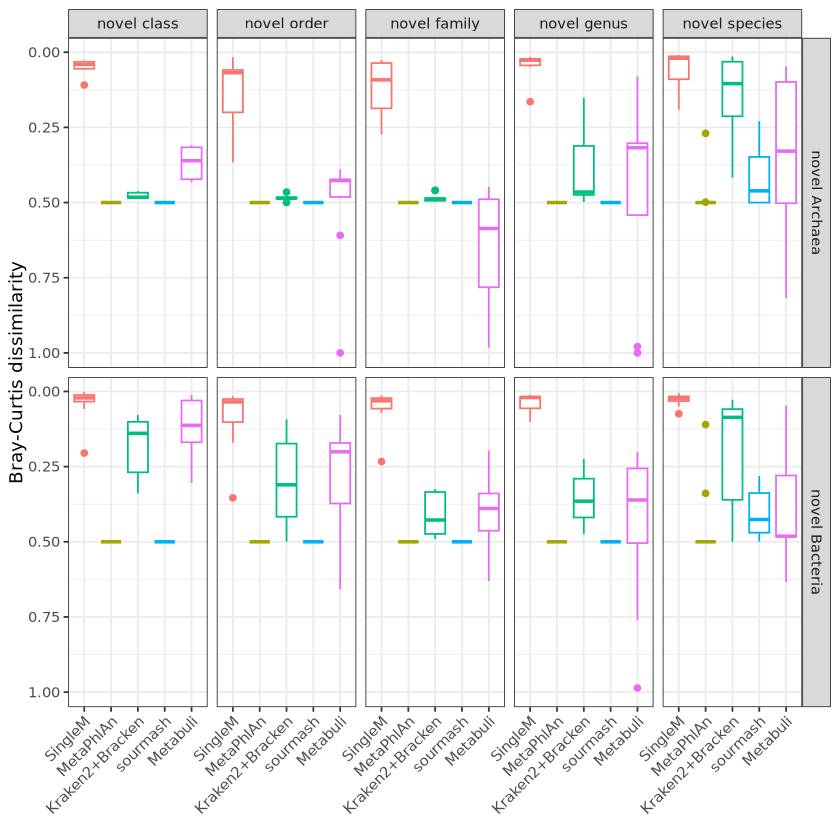

In [21]:
# What about when the rank equals one level above the novelty category?
bc2[tool=='singlem', tool2 := 'SingleM']
bc2[tool=='metaphlan', tool2 := 'MetaPhlAn']
bc2[tool=='motus', tool2 := 'mOTUs']
bc2[tool=='kraken', tool2 := 'Kraken2+Bracken']
bc2[tool=='sourmash', tool2 := 'sourmash']
bc2[tool=='kaiju', tool2 := 'Kaiju']
bc2[tool=='coverm', tool2 := 'CoverM']
bc2[tool=='metabuli', tool2 := 'Metabuli']
tools2_order = c('SingleM','MetaPhlAn','Kraken2+Bracken','sourmash','Metabuli')
bc2[, tool2 := factor(tool2, levels=tools2_order)]

bc2[, novelty_category_novel := factor(gsub('^','novel ',novelty_category), levels=novel_orders)]

qplot(data=bc2[tool %in% correct_taxonomy_tools][novelty_category != 'phylum'][rank==orders[as.numeric(novelty_category)-2]], colour=tool, ylab='Bray-Curtis dissimilarity', tool2, value, geom='boxplot', xlab='')+facet_grid(kingdom~novelty_category_novel)+theme(axis.text.x = element_text(angle = 45, hjust = 1))+theme(legend.position='none')+scale_y_reverse()

In [22]:
bc2[tool %in% correct_taxonomy_tools][novelty_category != 'phylum'][rank==orders[as.numeric(novelty_category)-2]][, .(ave=mean(value), sd=sd(value)), by=list(tool)]

tool,ave,sd
<fct>,<dbl>,<dbl>
singlem,0.06304213,0.07413085
metaphlan,0.49217637,0.04763711
kraken,0.33055911,0.16388030
sourmash,0.48208153,0.05460744
metabuli,0.38186946,0.23950731


In [23]:
# Write out data for plotting benchmarks altogether
fwrite(bc2, 'bray_curtis.tsv', sep='\t')

# How much does SingleM over-classify to the species level?

In [24]:
# Read in the singlem .profile file for each species
profiles = data.table(expand.grid(tool=tools, genome=strats$genome))
profiles2 = profiles[, fread(paste('output_',tool,'/',tool,'/',genome,'.profile',sep=''), sep='\t',colClasses=c('character','numeric','character')), by=.(tool,genome)]
profiles2[1:3]

tool,genome,sample,coverage,taxonomy
<fct>,<fct>,<chr>,<dbl>,<chr>
singlem,GCA_019422935.1_genomic,GCA_019422935.1_genomic.1,0.43,Root; d__Archaea
singlem,GCA_019422935.1_genomic,GCA_019422935.1_genomic.1,0.05,Root; d__Bacteria
singlem,GCA_019422935.1_genomic,GCA_019422935.1_genomic.1,0.11,Root; d__Archaea; p__Halobacteriota; c__Halobacteria; o__Halobacteriales; f__Haloferacaceae


In [25]:
# Only care about s__ entries. Then order by abundance reverse, remove the top one.
get_abundance_of_non_top_species = function(sd) {
    # sd[, is_non_novel := F]
    # sd[grep('s__Staphylococcus aureus', taxonomy), is_non_novel := T]
    # sd[grep('s__Methanobrevibacter ruminantium', taxonomy), is_non_novel := T]
    return(sd[is_non_novel==F, sum(coverage)] / sum(sd$coverage))
    # print(sd)
    # if (nrow(sd) == 1) {
    #     return(0)
    # } else {
    #     return(sd[2:nrow(sd), sum(coverage)] / sum(sd$coverage[1]))
    # }
}
profiles2[, is_non_novel := F]

# Read genome_pairs.tsv and extract
genome_pairs = fread('genome_pairs.tsv',sep='\t')
for (tax in genome_pairs$paired_taxonomy){
    profiles2[grep(gsub('.*;','',tax), taxonomy), is_non_novel := T]
}
# profiles2[grep('s__Staphylococcus aureus', taxonomy), is_non_novel := T]
# profiles2[grep('s__Methanobrevibacter ruminantium', taxonomy), is_non_novel := T]

overclassification_rates = profiles2[grep('s__',taxonomy)][order(-coverage)][,.(overclassification=get_abundance_of_non_top_species(.SD)), by=.(tool,genome)]
summary(overclassification_rates[tool=='singlem']$overclassification)

overclassification_rates[tool=='singlem'][overclassification > 0.3]
table(overclassification_rates$tool)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.02858 0.00000 0.47497 

tool,genome,overclassification
<fct>,<fct>,<dbl>
singlem,GCA_019422935.1_genomic,0.4749750
singlem,GCA_020161365.1_genomic,0.4015107
singlem,GCA_020860125.1_genomic,0.3150502
singlem,GCA_019459085.1_genomic,0.3304721
singlem,GCA_020053305.1_genomic,0.3020990
singlem,GCF_021184045.1_genomic,0.4462602
singlem,GCF_024707485.1_genomic,0.4081633



  singlem metaphlan     motus    kraken  sourmash     kaiju     map2b  metabuli 
      120       120       120       120       120       120       120       120 

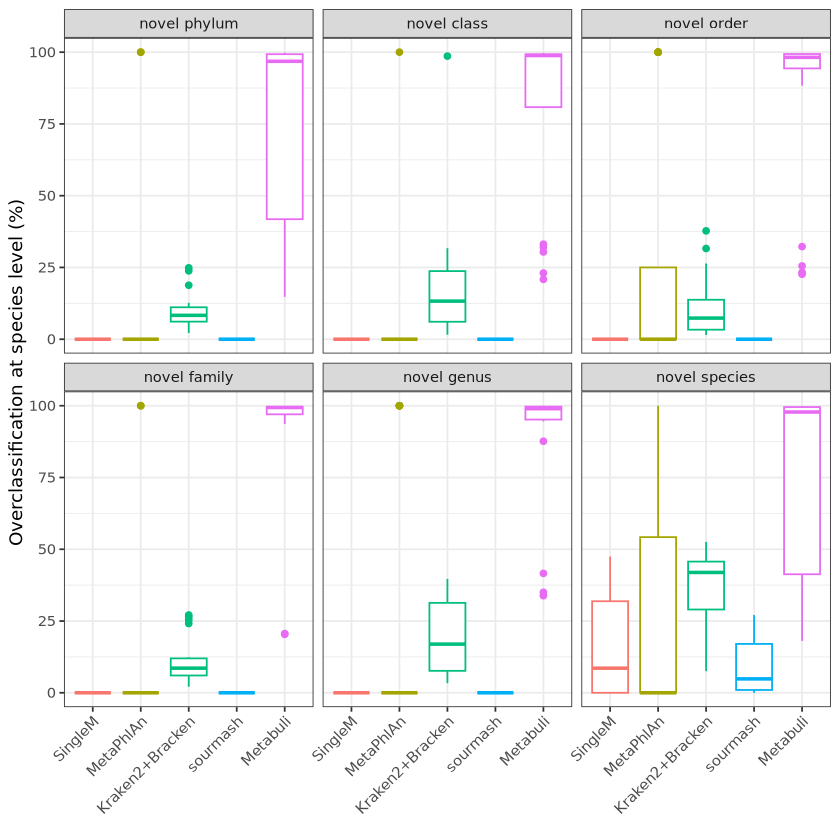

In [26]:
# What about per-taxon level?
overclassification_rates2 = merge(overclassification_rates, strats, by='genome')

overclassification_rates2[tool=='singlem', tool2 := 'SingleM']
overclassification_rates2[tool=='metaphlan', tool2 := 'MetaPhlAn']
overclassification_rates2[tool=='motus', tool2 := 'mOTUs']
overclassification_rates2[tool=='kraken', tool2 := 'Kraken2+Bracken']
overclassification_rates2[tool=='sourmash', tool2 := 'sourmash']
overclassification_rates2[tool=='kaiju', tool2 := 'Kaiju']
overclassification_rates2[tool=='coverm', tool2 := 'CoverM']
overclassification_rates2[tool=='map2b', tool2 := 'MAP2B']
overclassification_rates2[tool=='metabuli', tool2 := 'Metabuli']
tools2_order = c('SingleM','MetaPhlAn','mOTUs','Kraken2+Bracken','sourmash','Kaiju','CoverM','Metabuli')
overclassification_rates2[, tool2 := factor(tool2, levels=tools2_order)]

overclassification_rates2[, novelty_category_novel := factor(gsub('^','novel ',novelty_category), levels=novel_orders)]

qplot(data=overclassification_rates2[tool %in% correct_taxonomy_tools][tool != 'coverm'], tool2, overclassification*100, ylab='Overclassification at species level (%)', xlab='', geom='boxplot', colour=tool2)+facet_wrap(~novelty_category_novel)+theme(axis.text.x = element_text(angle = 45, hjust = 1))+theme(legend.position='none')

In [27]:
# So at the novel species level
summary(overclassification_rates2[tool=='singlem'][novelty_category=='species', overclassification])
sd(overclassification_rates2[tool=='singlem'][novelty_category=='species', overclassification])
summary(overclassification_rates2[tool=='metaphlan'][novelty_category=='species', overclassification])
summary(overclassification_rates2[tool=='motus'][novelty_category=='species', overclassification])
summary(overclassification_rates2[tool=='kraken'][novelty_category=='species', overclassification])
summary(overclassification_rates2[tool=='sourmash'][novelty_category=='species', overclassification])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.08571 0.17149 0.31891 0.47497 

[1] 0.1848879

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.2891  0.5422  1.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.75    1.00    0.75    1.00    1.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.07545 0.29014 0.41924 0.36017 0.45702 0.52575 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.009761 0.048444 0.089985 0.170264 0.270833 

In [28]:
# Overclassification to species level of kraken when genome is more novel than species-level
summary(overclassification_rates2[tool=='kraken'][novelty_category!='species', overclassification])
sd(overclassification_rates2[tool=='kraken'][novelty_category!='species', overclassification])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.01464 0.06044 0.09147 0.13802 0.21216 0.98626 

[1] 0.1303149

# With mOTUs, how much is unassigned to any kingdom?

In [29]:
# Read the profile file for each genome
motus_profiles = data.table(expand.grid(tool='motus', genome=strats$genome))
motus_profiles2 = motus_profiles[, fread(paste('output_',tool,'/',tool,'/',genome,'.motus',sep=''), sep='\t',colClasses=c('character','numeric')), by=.(tool,genome)]
# add novelty category
motus_profiles2 = merge(motus_profiles2, strats, by='genome')
setnames(motus_profiles2, 'unnamed sample', 'relabund')
setnames(motus_profiles2, '#consensus_taxonomy', 'taxon')
motus_profiles2[1:5]

genome,tool,taxon,relabund,novelty_category,taxonomy
<chr>,<fct>,<chr>,<dbl>,<chr>,<chr>
GCA_013154095.1_genomic,motus,k__Bacteria,1,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,motus,k__Archaea,0,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,motus,k__Eukaryota,0,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,motus,k__Unknown cellular organism,0,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095
GCA_013154095.1_genomic,motus,unassigned,0,phylum,d__Archaea;p__JAADDD01;c__JAADDD01;o__JAADDD01;f__JAADDD01;g__JAADDD01;s__JAADDD01 sp013154095


In [30]:
# We set the total unassigned to 0.5, maximum, because that is the best possible scenario for the tool
unassigned_motus = motus_profiles2[taxon == 'unassigned']
unassigned_motus[relabund > 0.5, relabund := 0.5]
unassigned_motus[,.N, by=novelty_category]
unassigned_motus[,.(ave=mean(relabund), sd=sd(relabund))]
unassigned_motus[,.(ave=mean(relabund), sd=sd(relabund)), by=list(novelty_category)]

novelty_category,N
<chr>,<int>
phylum,20
family,20
species,20
order,20
genus,20
class,20


ave,sd
<dbl>,<dbl>
0.07484706,0.1655776


novelty_category,ave,sd
<chr>,<dbl>,<dbl>
phylum,0.02500000,0.1118034
family,0.09903194,0.1914375
species,0.07025627,0.1412970
order,0.05150642,0.1289303
genus,0.10148548,0.2044929
class,0.10180222,0.1970237
